# <center>**Deep Learning Model(LSTM)**</center>

In this notebook, we build an LSTM to predict high-frequency limit order book movements. LSTMs are excellent at capturing temporal dependencies in time-series data.

---
## Google Colab Instructions
If you are running this on Google Colab:
1. Go to **Runtime > Change runtime type** and select **T4 GPU**.
2. Upload your `train.parquet`, `val.parquet`, and `test.parquet` files directly to the Colab files pane, or mount your Google Drive using the cell below.

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, accuracy_score, classification_report, ConfusionMatrixDisplay

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))

Using device: cuda
Tesla T4


In [ ]:
# Optional: If using Google Drive in Colab, uncomment and run:
# from google.colab import drive
# drive.mount('/content/drive')
# %cd /content/drive/MyDrive/path_to_your_project/

### 1. PyTorch Dataset (Sliding Window)
LSTMs need sequences of data. We'll write a custom PyTorch `Dataset` that takes our flat dataframe and returns sliding windows of length `T`. For example, if `T=50`, to predict the label at time `t`, the model gets features from `t-49` up to `t`.

In [ ]:
class LOBDataset(Dataset):
    def __init__(self, df, feature_cols, target_col, seq_length=50):
        """
        df: pandas DataFrame containing the data
        feature_cols: list of column names for features
        target_col: column name for the label
        seq_length: how many past ticks to include in one sequence
        """
        self.seq_length = seq_length

        # Convert to numpy arrays for fast slicing
        self.features = df[feature_cols].values.astype(np.float32)

        # Labels are -1, 0, 1. PyTorch CrossEntropyLoss expects classes to be 0-indexed.
        # We map: -1 -> 0, 0 -> 1, 1 -> 2
        self.labels = df[target_col].values.astype(np.int64) + 1

    def __len__(self):
        # We can only create sequences if we have enough historical data
        return len(self.features) - self.seq_length + 1

    def __getitem__(self, idx):
        # Get sequence of features
        x = self.features[idx : idx + self.seq_length]
        # The label is the target for the *last* tick in the sequence
        y = self.labels[idx + self.seq_length - 1]

        return torch.tensor(x), torch.tensor(y)

In [ ]:
# Hyperparameters
SEQ_LENGTH = 50
BATCH_SIZE = 512

FEATURE_COLS = ['mid_price', 'spread', 'vol_imbalance_1', 'vol_imbalance_5', 'weighted_mid']
TARGET_COL = 'label'

# Load Data
print("Loading parquets...")
train_df = pd.read_parquet('./sample_data/train.parquet')
val_df   = pd.read_parquet('./sample_data/val.parquet')
test_df  = pd.read_parquet('./sample_data/test.parquet')

# Create Datasets
train_dataset = LOBDataset(train_df, FEATURE_COLS, TARGET_COL, SEQ_LENGTH)
val_dataset   = LOBDataset(val_df, FEATURE_COLS, TARGET_COL, SEQ_LENGTH)
test_dataset  = LOBDataset(test_df, FEATURE_COLS, TARGET_COL, SEQ_LENGTH)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train sequences: {len(train_dataset):,}")
print(f"Val sequences:   {len(val_dataset):,}")
print(f"Test sequences:  {len(test_dataset):,}")

Loading parquets...
Train sequences: 346,948
Val sequences:   74,307
Test sequences:  74,308


### 2. LSTM Architecture
We use a 2-layer LSTM followed by a fully connected (Linear) layer to output logits for our 3 classes.

In [ ]:
class LOBPredictor(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.2):
        super(LOBPredictor, self).__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x shape: (batch_size, seq_length, input_size)

        # lstm_out shape: (batch_size, seq_length, hidden_size)
        # hidden shape: (num_layers, batch_size, hidden_size)
        lstm_out, (hidden, cell) = self.lstm(x)

        # We only care about the output from the final time step
        out = lstm_out[:, -1, :]

        # Pass through fully connected layer
        logits = self.fc(out)
        return logits

### 3. Training Loop & Early Stopping
We will compute the Macro F1-Score on the validation set at the end of every epoch. If the score doesn't improve for `PATIENCE` epochs, we stop early to prevent overfitting.

In [ ]:
def evaluate(model, loader, criterion):
    model.eval()
    val_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            logits = model(x)
            loss = criterion(logits, y)
            val_loss += loss.item() * x.size(0)

            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    val_loss = val_loss / len(loader.dataset)
    f1 = f1_score(all_labels, all_preds, average='macro')

    return val_loss, f1

def train_model(model, train_loader, val_loader, epochs=20, patience=5):
    # Handle class imbalance by providing weights to CrossEntropyLoss
    # Assuming the classes are roughly equally unbalanced as seen in Phase 3
    # If they are severely imbalanced, consider calculating exact inverse frequencies here
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    best_f1 = 0.0
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        # Use tqdm for a nice progress bar
        loop = tqdm(train_loader, leave=False)
        for x, y in loop:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * x.size(0)
            loop.set_description(f"Epoch [{epoch+1}/{epochs}]")
            loop.set_postfix(loss=loss.item())

        train_loss = train_loss / len(train_loader.dataset)
        val_loss, val_f1 = evaluate(model, val_loader, criterion)

        print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val F1: {val_f1:.4f}")

        # Early Stopping check
        if val_f1 > best_f1:
            best_f1 = val_f1
            patience_counter = 0
            torch.save(model.state_dict(), 'best_lstm.pt')
            print(f"  -> Best model saved!")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\nEarly stopping triggered after {epoch+1} epochs.")
                break

    print("Training complete.")

In [ ]:
# Initialize Model
model = LOBPredictor(
    input_size=len(FEATURE_COLS),
    hidden_size=64,
    num_layers=2,
    num_classes=3,
    dropout=0.2
).to(device)

# Start Training
train_model(model, train_loader, val_loader, epochs=30, patience=5)

  0%|          | 0/678 [00:00<?, ?it/s]

Epoch 01 | Train Loss: 0.0742 | Val Loss: 0.0503 | Val F1: 0.3320
  -> Best model saved!


  0%|          | 0/678 [00:00<?, ?it/s]

Epoch 02 | Train Loss: 0.0487 | Val Loss: 0.0499 | Val F1: 0.3320


  0%|          | 0/678 [00:00<?, ?it/s]

...

Epoch 11 | Train Loss: 0.0467 | Val Loss: 0.0493 | Val F1: 0.3320


  0%|          | 0/678 [00:00<?, ?it/s]

Epoch 12 | Train Loss: 0.0465 | Val Loss: 0.0494 | Val F1: 0.3320


  0%|          | 0/678 [00:00<?, ?it/s]

Epoch 13 | Train Loss: 0.0463 | Val Loss: 0.0491 | Val F1: 0.3341

Early stopping triggered after 13 epochs.
Training complete.


### 4. Final Evaluation (Test Set)
Let's load the best model weights and see if we can beat the Random Forest baseline!

Evaluating Test Set:   0%|          | 0/146 [00:00<?, ?it/s]


=== TEST SET PERFORMANCE ===
Macro F1: 0.3319
Accuracy: 0.9913



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

        DOWN       0.00      0.00      0.00       347
  STATIONARY       0.99      1.00      1.00     73664
          UP       0.00      0.00      0.00       297

    accuracy                           0.99     74308
   macro avg       0.33      0.33      0.33     74308
weighted avg       0.98      0.99      0.99     74308



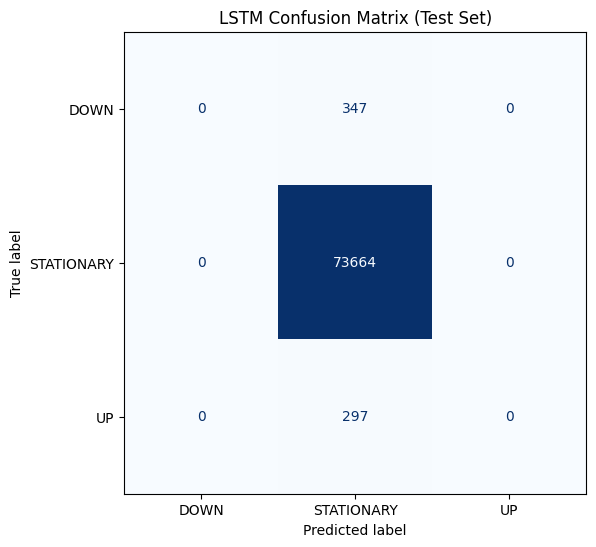

In [ ]:
# Load best weights
model.load_state_dict(torch.load('best_lstm.pt'))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for x, y in tqdm(test_loader, desc="Evaluating Test Set"):
        x, y = x.to(device), y.to(device)
        logits = model(x)
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

# Note: our classes are mapped 0, 1, 2. Let's map them back for the report.
class_names = ['DOWN', 'STATIONARY', 'UP']

print("\n=== TEST SET PERFORMANCE ===")
print(f"Macro F1: {f1_score(all_labels, all_preds, average='macro'):.4f}")
print(f"Accuracy: {accuracy_score(all_labels, all_preds):.4f}\n")
print(classification_report(all_labels, all_preds, target_names=class_names))

fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(
    all_labels, all_preds,
    display_labels=class_names,
    cmap='Blues',
    colorbar=False,
    ax=ax
)
plt.title('LSTM Confusion Matrix (Test Set)')
plt.show()